### Problem Statement-

Design a fraud detection system to identify fraudulent credit card transactions in real-time. The system should detect suspicious activities such as unauthorized transactions, unusual spending patterns, and fraudulent card usage to prevent financial losses for both cardholders and financial institutions.

In [1]:
# Load library package
import pandas as pd  # organise and manipulate the data
import numpy as np   # Scientifical computation package
import matplotlib.pyplot as plt # visualization
import seaborn as sns           # Visulaization
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
data = pd.read_csv('cc_data.csv')
print("==="*10)
print("data has successfully loaded..")


data has successfully loaded..


In [3]:
data.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23/03/19 3:06,3.586008e+15,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29/02/84,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0.0
1,1185025,10/05/20 11:28,4.671727e+15,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25/07/55,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0.0
2,10818,07/01/19 13:31,3.779930e+14,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11/09/75,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0.0
3,975275,30/01/20 18:49,4.710826e+18,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04/01/64,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0.0
4,346814,12/06/19 3:04,3.723820e+14,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21/01/66,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0.0


In [4]:
data.tail(2)

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
28460,583949,04/09/19 18:17,4.951647e+15,"fraud_Walter, Hettinger and Kessler",personal_care,11.3,Kimberly,Miller,F,75533 Tamara Valleys,...,37.9943,-88.9417,324,"Scientist, research (physical sciences)",15/06/76,8c0749f4b6950ba643a07c752afa52eb,1346782632,38.255527,-89.398383,0.0
28461,1272527,12/06/20 19:24,2.131420e+14,fraud_Bechtelar-Rippin,food_dining,74.1,Margaret,Curtis,F,742 Oneill Shore,...,32.1530,-90.1217,19685,Fine artist,24/12/84,511cce507d0a0f7d9dc4a147414a41c5,1371065055,31.974500,NaN,NaN


In [5]:
# Summary of dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28462 entries, 0 to 28461
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  28462 non-null  int64  
 1   trans_date_trans_time  28462 non-null  object 
 2   cc_num                 28462 non-null  float64
 3   merchant               28462 non-null  object 
 4   category               28462 non-null  object 
 5   amt                    28462 non-null  float64
 6   first                  28462 non-null  object 
 7   last                   28462 non-null  object 
 8   gender                 28462 non-null  object 
 9   street                 28462 non-null  object 
 10  city                   28462 non-null  object 
 11  state                  28462 non-null  object 
 12  zip                    28462 non-null  int64  
 13  lat                    28462 non-null  float64
 14  long                   28462 non-null  float64
 15  ci

### Task-1: What are the dimensions (number of rows and columns) of the dataset?

In [6]:
# Knowing the dimension of dataframe
print("The dimension of dataset is:", data.shape)

The dimension of dataset is: (28462, 23)


### Task-2: How many unique values are there in each categorical variable?

In [7]:
categorical_columns = data.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')


In [8]:
for col in categorical_columns:
  print(f"{col} has unique values : {data[col].nunique()}")

trans_date_trans_time has unique values : 27839
merchant has unique values : 693
category has unique values : 14
first has unique values : 341
last has unique values : 468
gender has unique values : 2
street has unique values : 927
city has unique values : 851
state has unique values : 50
job has unique values : 482
dob has unique values : 912
trans_num has unique values : 28462


### Task-3: What is the distribution of numerical variables in the dataset?

In [9]:
# Based on domain knowledge and understanding, let take amt and city_pop variables for distribution analysis.
num_data = data[['amt', 'city_pop']].copy()
num_data.head(3)

,amt,city_pop
0,1.24,50489
1,112.57,2304
2,6.69,5548


In [10]:
# Distribution of the columns
num_data.describe()

,amt,city_pop
count,28462.000000,2.846200e+04
mean,72.352412,9.103926e+04
std,205.419209,3.043625e+05
min,1.000000,2.300000e+01
25%,9.670000,7.430000e+02
50%,47.945000,2.435000e+03
75%,83.200000,2.032800e+04
max,15305.950000,2.906700e+06


### Findings:
1. amt is a right skewed distribution since the mean is greater than the median of data.
2. City_pop is also a right skewed distribution.

### Task-4:Are there any missing values in the dataset? If so, how should they be handled?

In [11]:
#Knowing missing values
data.isnull().sum()

,0
index,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


### Handling of missing values:
1. For categorical columns use mode as imputation value
2. For numerical columns use mean (when the distribution is symmetric) or median(when distribution is skewed) to impute missing values

### Task-5: What are the summary statistics (mean, median, min, max, etc.) for numerical variables?

In [12]:
# Distribution of the columns
num_data.describe()

,amt,city_pop
count,28462.000000,2.846200e+04
mean,72.352412,9.103926e+04
std,205.419209,3.043625e+05
min,1.000000,2.300000e+01
25%,9.670000,7.430000e+02
50%,47.945000,2.435000e+03
75%,83.200000,2.032800e+04
max,15305.950000,2.906700e+06


### Task 6: Is there any correlation between numerical variables? If so, how strong is the correlation?

In [13]:
num_data.corr()

,amt,city_pop
amt,1.00000,0.00541
city_pop,0.00541,1.00000


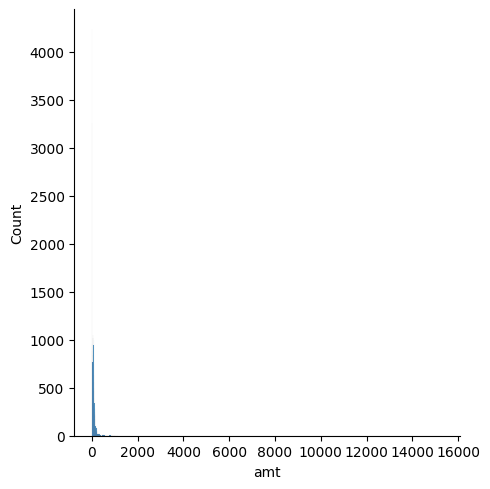

In [14]:
# Draw the distibution of numerical variables
sns.displot(data= num_data, x = 'amt')
plt.show()

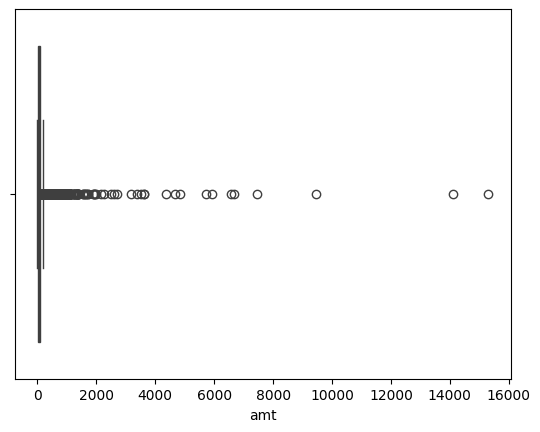

In [15]:
sns.boxplot(data= num_data, x = 'amt')
plt.show()

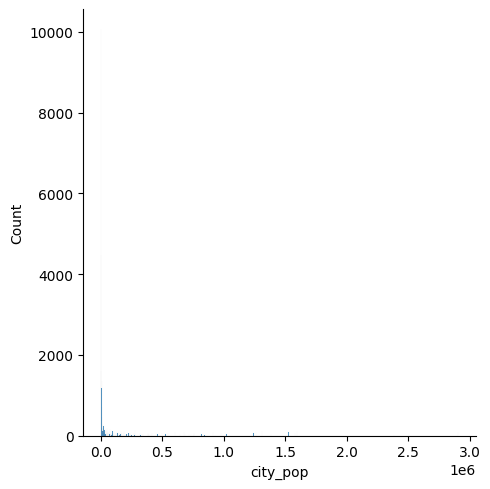

In [16]:
sns.displot(data= num_data, x = 'city_pop')
plt.show()

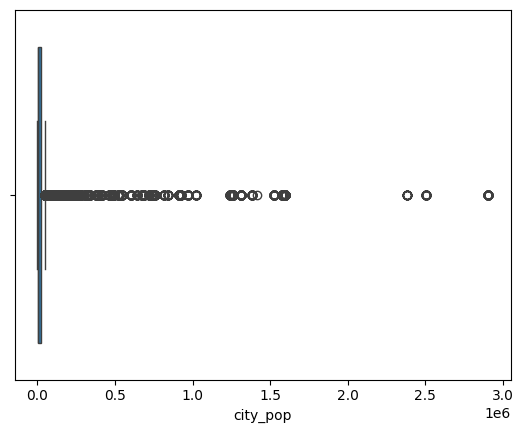

In [17]:
sns.boxplot(data= num_data, x = 'city_pop')
plt.show()

### Task 7: How does the distribution of an amt differ across is_fraud categories?

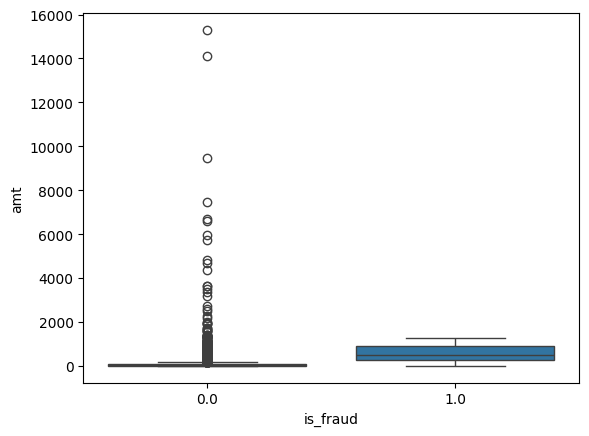

In [18]:
sns.boxplot(data= data, x = 'is_fraud', y ='amt')
plt.show()

### TAsk-8: Are there any outliers in the city_pop and amt?

In [19]:
# Number of outliers in amt column
Q1 = data['amt'].quantile(0.25)
Q3 = data['amt'].quantile(0.75)
IQR = Q3 - Q1
# Rule of outlier: x < Q1-1.5*IQR or x > Q3+1.5*IQR is outlier
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
amt_outliers = data[(data['amt'] < lower_bound) | (data['amt'] > upper_bound)].copy()
print("Number of outliers in amt column:", len(amt_outliers))

Number of outliers in amt column: 1477


### Task 9: Are there any trends or patterns in the data over time (if applicable)?

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28462 entries, 0 to 28461
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  28462 non-null  int64  
 1   trans_date_trans_time  28462 non-null  object 
 2   cc_num                 28462 non-null  float64
 3   merchant               28462 non-null  object 
 4   category               28462 non-null  object 
 5   amt                    28462 non-null  float64
 6   first                  28462 non-null  object 
 7   last                   28462 non-null  object 
 8   gender                 28462 non-null  object 
 9   street                 28462 non-null  object 
 10  city                   28462 non-null  object 
 11  state                  28462 non-null  object 
 12  zip                    28462 non-null  int64  
 13  lat                    28462 non-null  float64
 14  long                   28462 non-null  float64
 15  ci

In [21]:
# Convert the trans_date_trans_time column into datetime column type
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28462 entries, 0 to 28461
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   index                  28462 non-null  int64         
 1   trans_date_trans_time  28462 non-null  datetime64[ns]
 2   cc_num                 28462 non-null  float64       
 3   merchant               28462 non-null  object        
 4   category               28462 non-null  object        
 5   amt                    28462 non-null  float64       
 6   first                  28462 non-null  object        
 7   last                   28462 non-null  object        
 8   gender                 28462 non-null  object        
 9   street                 28462 non-null  object        
 10  city                   28462 non-null  object        
 11  state                  28462 non-null  object        
 12  zip                    28462 non-null  int64         
 13  l

In [22]:
time_data= data[['trans_date_trans_time', 'amt']].copy()
time_data.head(5)

,trans_date_trans_time,amt
0,2019-03-23 03:06:00,1.24
1,2020-10-05 11:28:00,112.57
2,2019-07-01 13:31:00,6.69
3,2020-01-30 18:49:00,100.69
4,2019-12-06 03:04:00,7.80


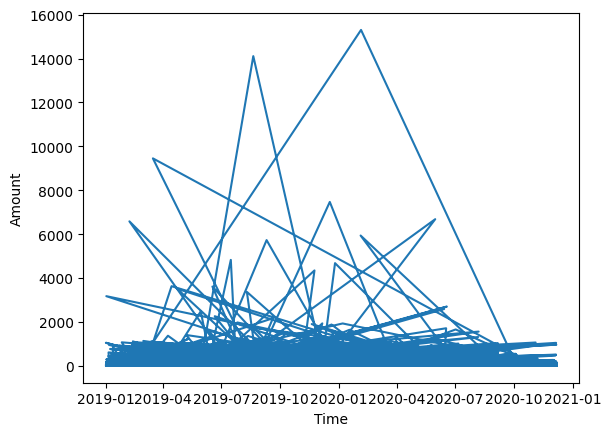

In [23]:
plt.plot(time_data['trans_date_trans_time'], time_data['amt'])
plt.xlabel('Time')
plt.ylabel('Amount')
plt.show()

In [24]:
# Sort the time_data using date column in ascending order
time_data = time_data.sort_values(by='trans_date_trans_time')
time_data.head()

,trans_date_trans_time,amt
4923,2019-01-01 00:22:00,3.66
26521,2019-01-01 01:39:00,68.24
15585,2019-01-01 02:54:00,1055.47
7426,2019-01-01 04:37:00,2.73
22007,2019-01-01 06:10:00,1.34


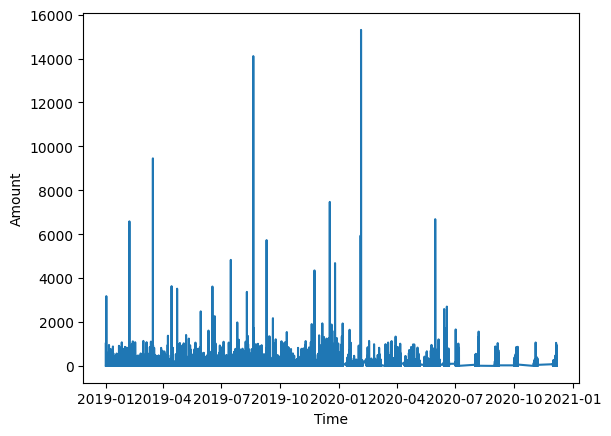

In [25]:
plt.plot(time_data['trans_date_trans_time'], time_data['amt'])
plt.xlabel('Time')
plt.ylabel('Amount')
plt.show()

### Task 10: How does the target variable (if available) distribute across different categories?

In [26]:
data.columns

Index(['index', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

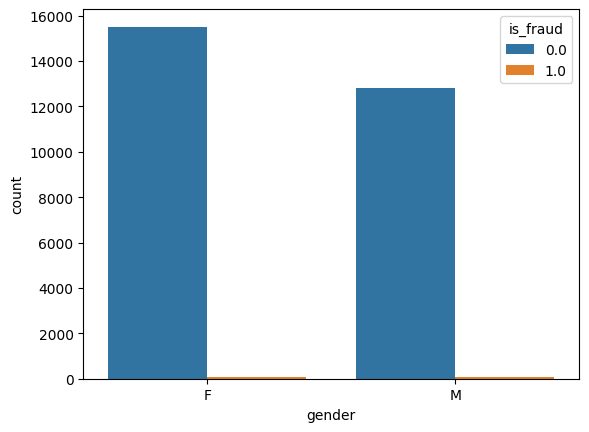

In [27]:
sns.countplot(data= data, x= 'gender', hue = 'is_fraud')
plt.show()

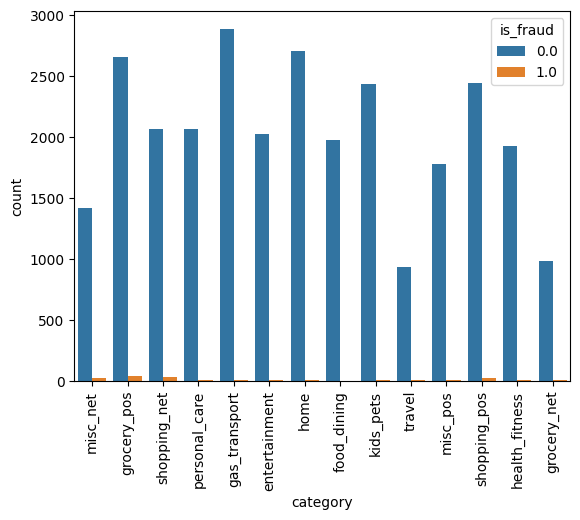

In [28]:
sns.countplot(data= data, x= 'category', hue = 'is_fraud')
plt.xticks(rotation=90)
plt.show()

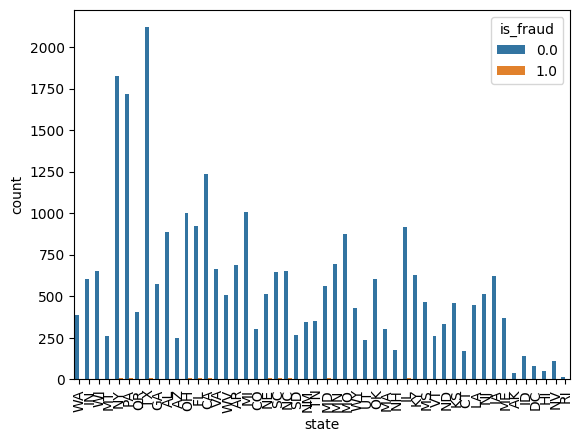

In [29]:
sns.countplot(data= data, x= 'state', hue = 'is_fraud')
plt.xticks(rotation=90)
plt.show()

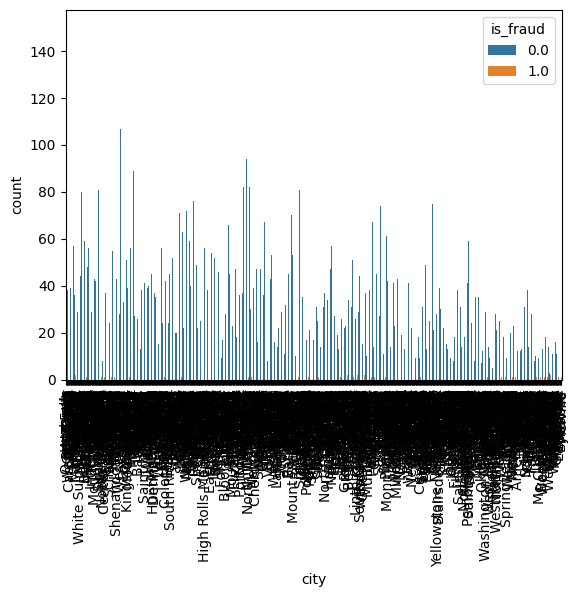

In [30]:
sns.countplot(data= data, x= 'city', hue = 'is_fraud')
plt.xticks(rotation=90)
plt.show()

### Task 11: Are there any unusual or unexpected values in the dataset that require further investigation?

In [31]:
data.columns

Index(['index', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [32]:
data['amt'].describe()

,amt
count,28462.000000
mean,72.352412
std,205.419209
min,1.000000
25%,9.670000
50%,47.945000
75%,83.200000
max,15305.950000


In [33]:
data['city_pop'].describe()

,city_pop
count,2.846200e+04
mean,9.103926e+04
std,3.043625e+05
min,2.300000e+01
25%,7.430000e+02
50%,2.435000e+03
75%,2.032800e+04
max,2.906700e+06


In [34]:
data['gender'].unique()

array(['F', 'M'], dtype=object)

In [35]:
data['category'].unique()

array(['misc_net', 'grocery_pos', 'shopping_net', 'personal_care',
       'gas_transport', 'entertainment', 'home', 'food_dining',
       'kids_pets', 'travel', 'misc_pos', 'shopping_pos',
       'health_fitness', 'grocery_net'], dtype=object)

In [36]:
data['job'].unique()

array(['Osteopath', 'Retail banker', 'Mining engineer',
       'Further education lecturer', 'Heritage manager', 'Archaeologist',
       'Film/video editor', 'Barrister', 'Psychiatrist',
       'Education officer, museum', 'Pensions consultant',
       'Pension scheme manager', 'Chemical engineer',
       'Petroleum engineer', 'Child psychotherapist',
       'Magazine features editor', 'Environmental health practitioner',
       'Exercise physiologist', 'Paediatric nurse',
       'Multimedia programmer', 'Buyer, industrial',
       'Designer, multimedia', 'Animator', 'Community development worker',
       'Nutritional therapist', 'Careers information officer',
       'Learning disability nurse', 'Engineer, electronics',
       'Television/film/video producer', 'Research scientist (maths)',
       'Biomedical engineer', 'Statistician', 'Chief Strategy Officer',
       'Hospital pharmacist', 'Charity officer', 'Journalist, newspaper',
       'Purchasing manager', 'Music tutor', 'Town pla

In [37]:
data['job'].nunique()

482

### Task 12: Are there any potential data entry errors or inconsistencies in the dataset?


In [38]:
# NO

### Task 13: How does the distribution of numerical variables vary between different groups or segments of the dataset?

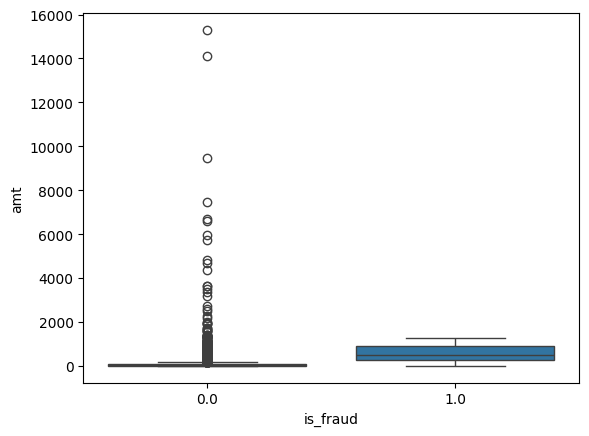

In [39]:
# Numerical variables- amt and city_pop
# Segments: Categorical Varibale- is_fruad(target variable), Gender, State, category
sns.boxplot(data= data, x= 'is_fraud', y= 'amt')
plt.show()

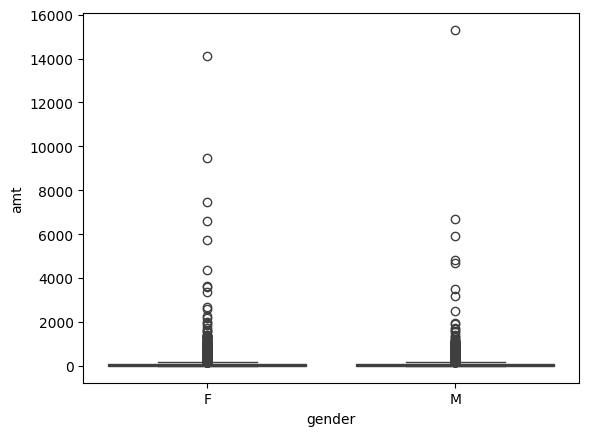

In [40]:
sns.boxplot(data= data, x= 'gender', y= 'amt')
plt.show()

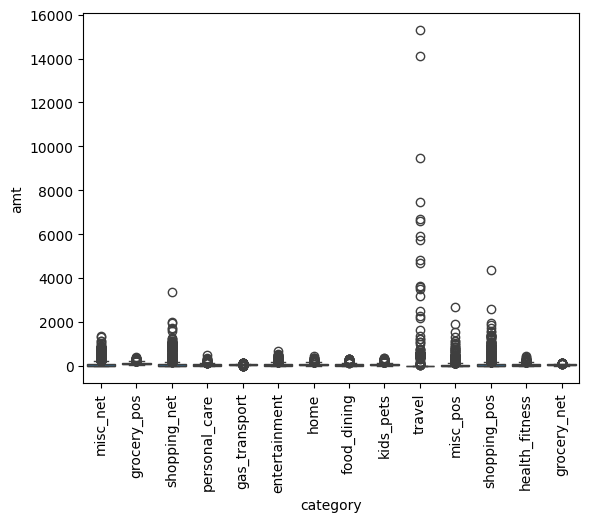

In [42]:
sns.boxplot(data= data, x= 'category', y= 'amt')
plt.xticks(rotation=90)
plt.show()